# Backdoor Criterion

## Setup

In [1]:
%%capture
%pip install dowhy==0.13 causaldata econml scikit-learn

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

from causaldata import nhefs
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import GradientBoostingRegressor

from dowhy import CausalModel
from econml.inference import BootstrapInference

- 금연이 체중 변화에 미치는 효과를 추정하고자 합니다.  
- 이를 위해 [**NHEFS (National Health and Nutrition Examination Survey – Epidemiologic Follow-up Study)**](https://rdrr.io/cran/causaldata/man/nhefs.html) 데이터를 활용합니다.  
- 이 데이터셋은 1971년 당시 흡연자였던 성인 코호트를 1982년까지 추적한 패널 자료로,  
금연 여부(`qsmk`, 1=금연, 0=계속 흡연), 체중 변화(`wt82_71`), 연령, 성별, 신체 활동 수준, 운동 습관 등 다양한 변수를 포함하고 있습니다.

In [2]:
df = nhefs.load_pandas().data.copy()

print("Shape of Data:")
print(df.shape)

print("Variable Names:")
print(df.columns)

df.head()

Shape of Data:
(1629, 67)
Variable Names:
Index(['seqn', 'qsmk', 'death', 'yrdth', 'modth', 'dadth', 'sbp', 'dbp', 'sex',
       'age', 'race', 'income', 'marital', 'school', 'education', 'ht', 'wt71',
       'wt82', 'wt82_71', 'birthplace', 'smokeintensity', 'smkintensity82_71',
       'smokeyrs', 'asthma', 'bronch', 'tb', 'hf', 'hbp', 'pepticulcer',
       'colitis', 'hepatitis', 'chroniccough', 'hayfever', 'diabetes', 'polio',
       'tumor', 'nervousbreak', 'alcoholpy', 'alcoholfreq', 'alcoholtype',
       'alcoholhowmuch', 'pica', 'headache', 'otherpain', 'weakheart',
       'allergies', 'nerves', 'lackpep', 'hbpmed', 'boweltrouble', 'wtloss',
       'infection', 'active', 'exercise', 'birthcontrol', 'pregnancies',
       'cholesterol', 'hightax82', 'price71', 'price82', 'tax71', 'tax82',
       'price71_82', 'tax71_82', 'id', 'censored', 'older'],
      dtype='object')


,seqn,qsmk,death,yrdth,modth,dadth,sbp,dbp,sex,age,...,hightax82,price71,price82,tax71,tax82,price71_82,tax71_82,id,censored,older
0,233.0,0.0,0.0,NaN,NaN,NaN,175.0,96.0,0,42.0,...,0.0,2.183594,1.739990,1.102295,0.461975,0.443787,0.640381,1,0.0,0.0
1,235.0,0.0,0.0,NaN,NaN,NaN,123.0,80.0,0,36.0,...,0.0,2.346680,1.797363,1.364990,0.571899,0.549316,0.792969,2,0.0,0.0
2,244.0,0.0,0.0,NaN,NaN,NaN,115.0,75.0,1,56.0,...,0.0,1.569580,1.513428,0.551270,0.230988,0.056198,0.320251,3,0.0,1.0
3,245.0,0.0,1.0,85.0,2.0,14.0,148.0,78.0,0,68.0,...,0.0,1.506592,1.451904,0.524902,0.219971,0.054794,0.304993,4,0.0,1.0
4,252.0,0.0,0.0,NaN,NaN,NaN,118.0,77.0,0,40.0,...,0.0,2.346680,1.797363,1.364990,0.571899,0.549316,0.792969,5,0.0,0.0


- **처치변수**: `qsmk` — 1982년 추적조사 시 금연 여부 (1=금연, 0=계속 흡연)  
- **결과변수**: `wt82_71` — 체중 변화량(kg) = 1982년 체중 – 1971년 체중  
- **통제변수**:  
  - `sex`: 성별 (0=남성, 1=여성)  
  - `age`: baseline 만 나이  
  - `race`: 인종 (0=백인, 1=기타)  
  - `education`: 학력 수준 (5단계 범주)  
  - `smokeintensity`: baseline 하루 평균 흡연량(개비)  
  - `smokeyrs`: 흡연 지속 기간(년)  
  - `active`: 일상생활 활동 수준 (3단계)  
  - `exercise`: 여가시간 운동 수준 (3단계)  
  - `wt71`: baseline 체중(kg)  


In [3]:
treatment = "qsmk"
outcome = "wt82_71"

confounders = [
    "sex",
    "age",              
    "race",             
    "education",        
    "smokeintensity",   
    "smokeyrs",         
    "active",           
    "exercise",         
    "wt71"              
]

vars_needed = [treatment, outcome] + confounders
df_clean = df[vars_needed].dropna()

print("처치군/대조군:\n", df_clean[treatment].value_counts())

처치군/대조군:
 qsmk
0.0    1163
1.0     403
Name: count, dtype: int64


## Model

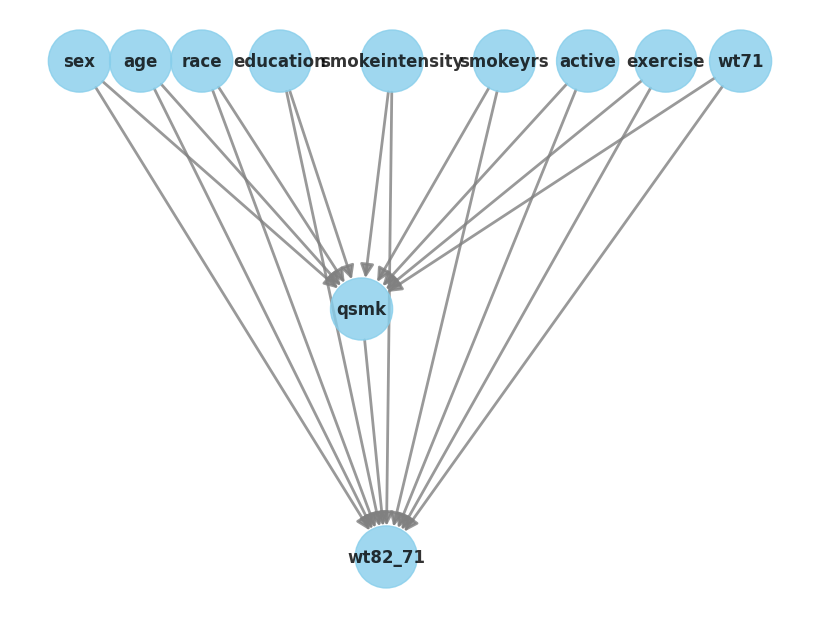

In [5]:
gml_graph = """
graph [
  directed 1

  node [ id "qsmk" label "qsmk" ]
  node [ id "wt82_71" label "wt82_71" ]

  node [ id "sex" label "sex" ]
  node [ id "age" label "age" ]
  node [ id "race" label "race" ]
  node [ id "education" label "education" ]
  node [ id "smokeintensity" label "smokeintensity" ]
  node [ id "smokeyrs" label "smokeyrs" ]
  node [ id "active" label "active" ]
  node [ id "exercise" label "exercise" ]
  node [ id "wt71" label "wt71" ]

  edge [ source "sex" target "qsmk" ]
  edge [ source "sex" target "wt82_71" ]
  edge [ source "age" target "qsmk" ]
  edge [ source "age" target "wt82_71" ]
  edge [ source "race" target "qsmk" ]
  edge [ source "race" target "wt82_71" ]
  edge [ source "education" target "qsmk" ]
  edge [ source "education" target "wt82_71" ]
  edge [ source "smokeintensity" target "qsmk" ]
  edge [ source "smokeintensity" target "wt82_71" ]
  edge [ source "smokeyrs" target "qsmk" ]
  edge [ source "smokeyrs" target "wt82_71" ]
  edge [ source "active" target "qsmk" ]
  edge [ source "active" target "wt82_71" ]
  edge [ source "exercise" target "qsmk" ]
  edge [ source "exercise" target "wt82_71" ]
  edge [ source "wt71" target "qsmk" ]
  edge [ source "wt71" target "wt82_71" ]

  edge [ source "qsmk" target "wt82_71" ]
]
"""

cm = CausalModel(data=df_clean, treatment=treatment, outcome=outcome, graph=gml_graph)
cm.view_model(
    layout="dot"
)

## Identify

In [ ]:
est_model = CausalModel(
    data=df_clean,
    treatment=treatment,
    outcome=outcome,
    graph=gml_graph
)

estimand = est_model.identify_effect()
print(estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
   d                                                                           ↪
───────(E[wt_82_71|sex,age,smokeyrs,race,active,wt71,education,exercise,smokei ↪
d[qsmk]                                                                        ↪

↪           
↪ ntensity])
↪           
Estimand assumption 1, Unconfoundedness: If U→{qsmk} and U→wt82_71 then P(wt82_71|qsmk,sex,age,smokeyrs,race,active,wt71,education,exercise,smokeintensity,U) = P(wt82_71|qsmk,sex,age,smokeyrs,race,active,wt71,education,exercise,smokeintensity)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
   d                                                                           ↪
───────(E[wt_82_71|sex,age,smokeyrs,race,active,wt71,education,exercise,smoke

- **Backdoor adjustment 가능**  
  모든 공변량을 조건화하면 `qsmk → wt82_71` 인과효과를 식별할 수 있습니다.

- **IV, Front-door 전략 없음**  
  도구변수(Instrument)나 매개변수(Mediator)로 활용할 만한 변수가 존재하지 않습니다.

- **가정 (Unconfoundedness)**  
  관측되지 않은 잠재적 교란 변수(U)가 `qsmk`와 `wt82_71` 모두에 동시에 영향을 주지 않는다고 가정해야 합니다.

따라서 **Back-door Adjustment**를 통해 금연(`qsmk`)이 체중 변화(`wt82_71`)에 미치는 ATE를 추정할 수 있습니다.

## Estimate

### 1. Linear Regression

In [7]:
estimate_lr = est_model.estimate_effect(
    identified_estimand=estimand,
    method_name="backdoor.linear_regression"
)
print("\n[ATE] Linear Regression:", estimate_lr.value)


[ATE] Linear Regression: 3.3811710339880823


### 2. Doubly Robust Learner

In [8]:
estimate_drl = est_model.estimate_effect(
    identified_estimand=estimand,
    method_name="backdoor.econml.dr.DRLearner",
    control_value=0,
    treatment_value=1,
    target_units="ate",
    confidence_intervals=True,
    method_params={
        "init_params": {
            "model_propensity": LogisticRegression(max_iter=5000),
            "model_regression": GradientBoostingRegressor(random_state=42)
        },
        "fit_params": {
            "inference": BootstrapInference(n_bootstrap_samples=500, n_jobs=-1)
        }
    }
)
print("[ATE] DR Learner:", estimate_drl.value)
print("[ATE] DR Learner 95% CI:", estimate_drl.get_confidence_intervals())


[ATE] DR Learner: 3.8479455513705227
[ATE] DR Learner 95% CI: [[[3.12167472]]

 [[5.29732315]]]


### 3. Double Machine Learning

In [9]:
estimate_dml = est_model.estimate_effect(
    identified_estimand=estimand,
    method_name="backdoor.econml.dml.DML",
    control_value=0,
    treatment_value=1,
    target_units="ate",
    confidence_intervals=True,
    method_params={
        "init_params": {
            "model_y": GradientBoostingRegressor(random_state=42),
            "model_t": GradientBoostingRegressor(random_state=42),
            "model_final": LinearRegression(fit_intercept=False),
        },
        "fit_params": {
            "inference": BootstrapInference(n_bootstrap_samples=500, n_jobs=-1)
        }
    }
)
print("[ATE] DML:", estimate_dml.value)
print("[ATE] DML 95% CI:", estimate_dml.get_confidence_intervals())



[ATE] DML: 3.8611289087159135
[ATE] DML 95% CI: [[[3.06774555]]

 [[5.17092571]]]


## Refute

In [15]:
estimate_dml_fast = est_model.estimate_effect(
    identified_estimand=estimand,
    method_name='backdoor.econml.dml.DML',
    method_params={
        'init_params': {
            'model_y': GradientBoostingRegressor(random_state=42),
            'model_t': GradientBoostingRegressor(random_state=42),
            'model_final': LinearRegression(fit_intercept=False),
        },
        'fit_params': {}}
)
print("[ATE] DML:", estimate_dml.value)

[ATE] DML: 3.8611289087159135


### 1. Add Random Common Cause

데이터셋에 독립적인 무작위 변수를 넣었을 때, 추정값이 바뀌는가?

- **기대**: New effect ≈ Estimated effect, p > 0.05

- **해석**: 크게 변하면 → 모델이 잡음에 민감하거나 과적합일 가능성

In [11]:
res_random=est_model.refute_estimate(
    estimand,
    estimate_dml_fast,
    method_name="random_common_cause"
)
print(res_random)

Refute: Add a random common cause
Estimated effect:3.5111934415796173
New effect:3.4686090208687586
p value:0.72



### 2. Add Unobserved Common Cause
데이터에 관찰되지 않은 교란요인이 존재한다고 가정했을 때, 추정값이 얼마나 변하는가?

- **기대**: New effect ≈ Estimated effect
- **해석**:
   - 크게 변하지 않으면 → 잠재적 누락변수(confounder) 에도 견고(robust)
   - 크게 변하면 → 모델이 숨은 교란에 민감, 추가 변수 고려 필요
- **참고**: 도메인 지식을 기반으로, 교란이 처리변수와 결과에 미치는 영향의 크기는 사용자가 직접 설정해야 합니다.

In [12]:
res_unobserved=est_model.refute_estimate(
    estimand,
    estimate_dml_fast,
    method_name="add_unobserved_common_cause",
    confounders_effect_on_treatment="linear",
    confounders_effect_on_outcome="linear",
    effect_strength_on_treatment=0.01,
    effect_strength_on_outcome=0.02
)
print(res_unobserved)

Refute: Add an Unobserved Common Cause
Estimated effect:3.5111934415796173
New effect:2.993841050044186



### 3. Placebo Treatment
처치 변수를 무작위로 섞인(permute) 가짜 처치(placebo)로 바꿨을 때, 추정값이 여전히 유의하게 나타나는가?

- **기대**: New effect ≈ 0, p > 0.05
- **해석**:
   - 효과가 사라지면 → 진짜 처치 효과만 반영된 것 → 견고(robust)
   - 여전히 유의하면 → 모델이 가짜 상관관계(spurious correlation) 를 잡고 있을 가능성

In [13]:
res_placebo=est_model.refute_estimate(
    estimand,
    estimate_dml_fast,
    method_name="placebo_treatment_refuter",
    placebo_type="permute",
    num_simulations=10
)
print(res_placebo)

Refute: Use a Placebo Treatment
Estimated effect:3.5111934415796173
New effect:0.14283539321647556
p value:0.3866345448655441



### 4. Use Subset of Data

데이터의 일부(예: 80%)만 무작위로 남겨두고 추정했을 때, 추정값이 얼마나 안정적인가?

- **기대**: New effect ≈ Estimated effect, p > 0.05

- **해석**:
  - 크게 변하지 않으면 → 표본 구성에 강건(robust)
  - 크게 변하면 → 특정 데이터 표본에 민감하거나, 과적합 가능성

In [14]:
res_subset=est_model.refute_estimate(
    estimand,
    estimate_dml_fast,
    method_name="data_subset_refuter",
    subset_fraction=0.8,
    num_simulations=10
)
print(res_subset)

Refute: Use a subset of data
Estimated effect:3.5111934415796173
New effect:3.4052136015402126
p value:0.4004970164482444

